# Olist E-Commerce — Sales Analysis

**Tools:** Python · pandas · matplotlib · seaborn · plotly · openpyxl  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Goal:** Analyse 100 000+ real orders to surface revenue trends, delivery
bottlenecks, and customer satisfaction gaps — then export a clean Excel
summary for stakeholders.

---

## Notebook structure
| # | Section | Key output |
|---|---------|------------|
| 1 | Setup & imports | — |
| 2 | Load & merge data | `master` dataframe |
| 3 | Data quality check | Null counts, dtype audit |
| 4 | Revenue trend | `monthly_revenue_trend.png` |
| 5 | Product category analysis | `top_categories.png` |
| 6 | Geographic analysis | `state_revenue.png` |
| 7 | Delivery performance | `delivery_analysis.png` |
| 8 | Customer reviews | `review_correlation.png` |
| 9 | Payment methods | `payment_methods.png` |
| 10 | Export Excel summary | `olist_analysis_summary.xlsx` |
| 11 | Business insights | Written summary |


## 1 — Setup & imports

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import seaborn              as sns

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────
DB_PATH  = Path('../olist.db')
OUT_PATH = Path('../outputs')
OUT_PATH.mkdir(exist_ok=True)

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
})

# Brand colours (used consistently across all charts)
BLUE   = '#378ADD'
ORANGE = '#D85A30'
GREEN  = '#1D9E75'
RED    = '#E24B4A'
PURPLE = '#7F77DD'
AMBER  = '#EF9F27'
GRAY   = '#888780'

print('Setup complete.')


Setup complete.


## 2 — Load & merge data

We load all tables from `olist.db` and join them into a single
`master` dataframe. Only **delivered** orders are kept — cancelled,
unavailable, and in-transit orders would distort revenue figures.


In [2]:
conn = sqlite3.connect(DB_PATH)

# Load individual tables
orders = pd.read_sql("""
    SELECT *
    FROM   orders
    WHERE  order_status = 'delivered'
      AND  order_delivered_customer_date IS NOT NULL
""", conn,
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
    ]
)

items       = pd.read_sql('SELECT * FROM order_items',    conn)
payments    = pd.read_sql('SELECT * FROM order_payments',  conn)
reviews     = pd.read_sql('SELECT * FROM order_reviews',   conn)
products    = pd.read_sql('SELECT * FROM products',        conn)
customers   = pd.read_sql('SELECT * FROM customers',       conn)
sellers     = pd.read_sql('SELECT * FROM sellers',         conn)
translation = pd.read_sql(
    'SELECT * FROM product_category_name_translation', conn
)
conn.close()

# Build master dataframe
master = (
    orders
    .merge(items,       on='order_id',   how='left')
    .merge(products,    on='product_id', how='left')
    .merge(translation, on='product_category_name', how='left')
    .merge(customers,   on='customer_id', how='left')
    .merge(reviews,     on='order_id',   how='left')
)

# ── Derived columns ──────────────────────────────────────────
master['total_value']   = master['price'] + master['freight_value']
master['month']         = master['order_purchase_timestamp'].dt.to_period('M')
master['month_str']     = master['month'].astype(str)
master['year']          = master['order_purchase_timestamp'].dt.year
master['quarter']       = master['order_purchase_timestamp'].dt.to_period('Q').astype(str)
master['delivery_days'] = (
    master['order_delivered_customer_date'] -
    master['order_purchase_timestamp']
).dt.days
master['is_late'] = (
    master['order_delivered_customer_date'] >
    master['order_estimated_delivery_date']
)

# Filter to full months with reliable data (Jan 2017 - Aug 2018)
master_full = master[
    (master['month_str'] >= '2017-01') &
    (master['month_str'] <= '2018-08')
].copy()

print(f'master shape    : {master.shape[0]:>8,} rows  |  {master.shape[1]} columns')
print(f'master_full     : {master_full.shape[0]:>8,} rows  (Jan 2017 – Aug 2018)')
print(f'unique orders   : {master_full["order_id"].nunique():>8,}')
print(f'unique customers: {master_full["customer_id"].nunique():>8,}')
print(f'unique products : {master_full["product_id"].nunique():>8,}')


master shape    :  110,832 rows  |  40 columns
master_full     :  110,511 rows  (Jan 2017 – Aug 2018)
unique orders   :   96,203
unique customers:   96,203
unique products :   32,079


In [3]:
master_full.head(3)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_comment_message,review_creation_date,review_answer_timestamp,total_value,month,month_str,year,quarter,delivery_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,38.71,2017-10,2017-10,2017,2017Q4,8,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,141.46,2018-07,2018-07,2018,2018Q3,13,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,None,2018-08-18 00:00:00,2018-08-22 19:07:58,179.12,2018-08,2018-08,2018,2018Q3,9,False


## 3 — Data quality check

Before drawing conclusions, confirm there are no unexpected nulls
or impossible values that could distort the analysis.


In [4]:
# Null % for key columns
key_cols = [
    'order_id', 'price', 'freight_value', 'total_value',
    'product_category_name_english', 'customer_state',
    'review_score', 'delivery_days', 'is_late',
]
null_pct = (
    master_full[key_cols].isnull().mean() * 100
).round(2).rename('null_%')
print(null_pct.to_string())

print()
print('Delivery days  — min:', master_full['delivery_days'].min(),
      ' max:', master_full['delivery_days'].max())
print('Price          — min:', master_full['price'].min(),
      ' max:', master_full['price'].max())
print('Review score   — min:', master_full['review_score'].min(),
      ' max:', master_full['review_score'].max())


order_id                         0.00
price                            0.00
freight_value                    0.00
total_value                      0.00
product_category_name_english    1.42
customer_state                   0.00
review_score                     0.74
delivery_days                    0.00
is_late                          0.00

Delivery days  — min: 0  max: 209
Price          — min: 0.85  max: 6735.0
Review score   — min: 1.0  max: 5.0


In [5]:
# Remove physically impossible delivery days (< 0)
bad_delivery = master_full['delivery_days'] < 0
print(f'Orders with negative delivery days: {bad_delivery.sum()} — dropping.')
master_full = master_full[~bad_delivery].copy()

# Fill missing category names with 'Unknown'
master_full['product_category_name_english'] = (
    master_full['product_category_name_english'].fillna('Unknown')
)
print('Data quality check complete.')


Orders with negative delivery days: 0 — dropping.
Data quality check complete.


## 4 — Revenue trend (monthly)

**Business question:** Is Olist growing month-over-month? When are
the seasonal peaks we should prepare for?


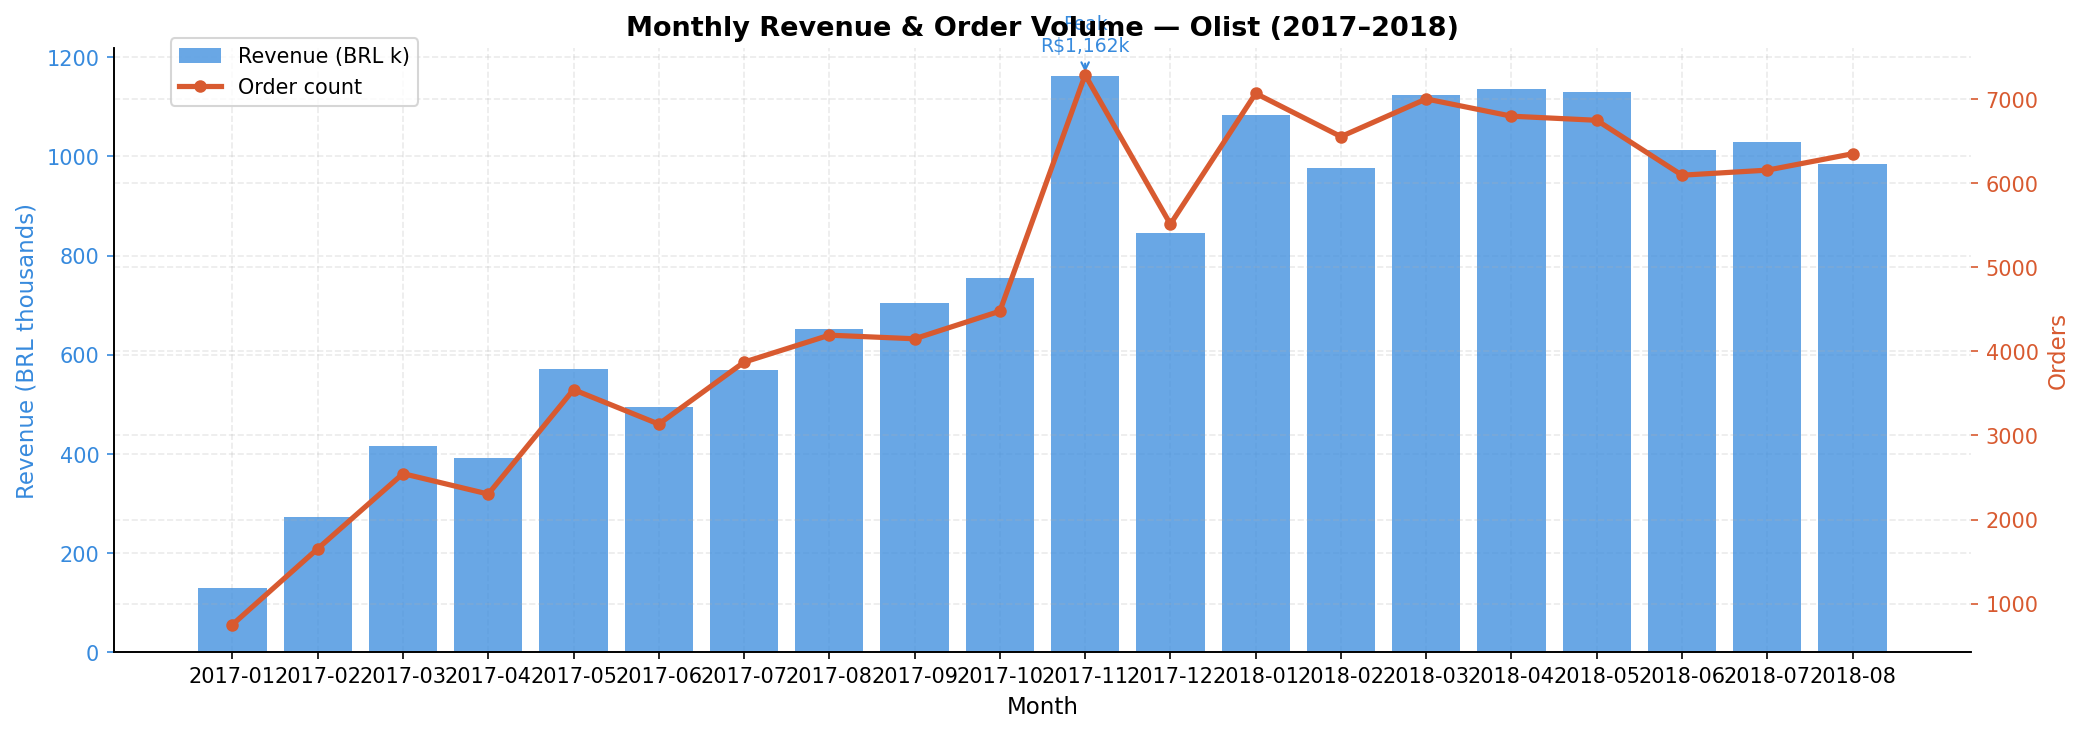

Total revenue (Jan17-Aug18): R$  15,441,452
First month revenue        : R$     128,454
Last  month revenue        : R$     985,596
Growth start→end           :       667.3%
Peak month                 :    2017-11
Max MoM growth             :    112.3%


In [6]:
monthly = (
    master_full
    .groupby('month_str')
    .agg(
        revenue   = ('total_value', 'sum'),
        orders    = ('order_id',    'nunique'),
        avg_value = ('total_value', 'mean'),
    )
    .reset_index()
)
monthly['mom_growth_pct'] = monthly['revenue'].pct_change() * 100
monthly['revenue_k']      = monthly['revenue'] / 1000

# ── Plot ────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Bar = revenue; line = order count
ax1.bar(monthly['month_str'], monthly['revenue_k'],
        color=BLUE, alpha=0.75, zorder=2, label='Revenue (BRL k)')
ax2.plot(monthly['month_str'], monthly['orders'],
         color=ORANGE, linewidth=2.5, marker='o', markersize=5,
         zorder=3, label='Order count')

# Annotate the peak month
peak_idx = monthly['revenue'].idxmax()
ax1.annotate(
    f"Peak\nR${monthly.loc[peak_idx,'revenue_k']:,.0f}k",
    xy=(monthly.loc[peak_idx,'month_str'], monthly.loc[peak_idx,'revenue_k']),
    xytext=(0, 12), textcoords='offset points',
    ha='center', fontsize=9, color=BLUE,
    arrowprops=dict(arrowstyle='->', color=BLUE, lw=1),
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (BRL thousands)', color=BLUE)
ax2.set_ylabel('Orders', color=ORANGE)
ax1.tick_params(axis='y', colors=BLUE)
ax2.tick_params(axis='y', colors=ORANGE)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax1.set_title('Monthly Revenue & Order Volume — Olist (2017–2018)')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.95), fontsize=10)
plt.tight_layout()
plt.savefig(OUT_PATH / 'monthly_revenue_trend.png', bbox_inches='tight')
plt.show()

# ── Key numbers ─────────────────────────────────────────────
total_rev   = monthly['revenue'].sum()
growth_pct  = (monthly['revenue'].iloc[-1] / monthly['revenue'].iloc[0] - 1) * 100
print(f'Total revenue (Jan17-Aug18): R${total_rev:>12,.0f}')
print(f'First month revenue        : R${monthly["revenue"].iloc[0]:>12,.0f}')
print(f'Last  month revenue        : R${monthly["revenue"].iloc[-1]:>12,.0f}')
print(f'Growth start→end           :    {growth_pct:>8.1f}%')
print(f'Peak month                 :    {monthly.loc[peak_idx,"month_str"]}')
print(f'Max MoM growth             :    {monthly["mom_growth_pct"].max():.1f}%')


## 5 — Product category analysis

**Business question:** Which categories drive the most revenue?
Do the top revenue categories also have the best customer ratings?


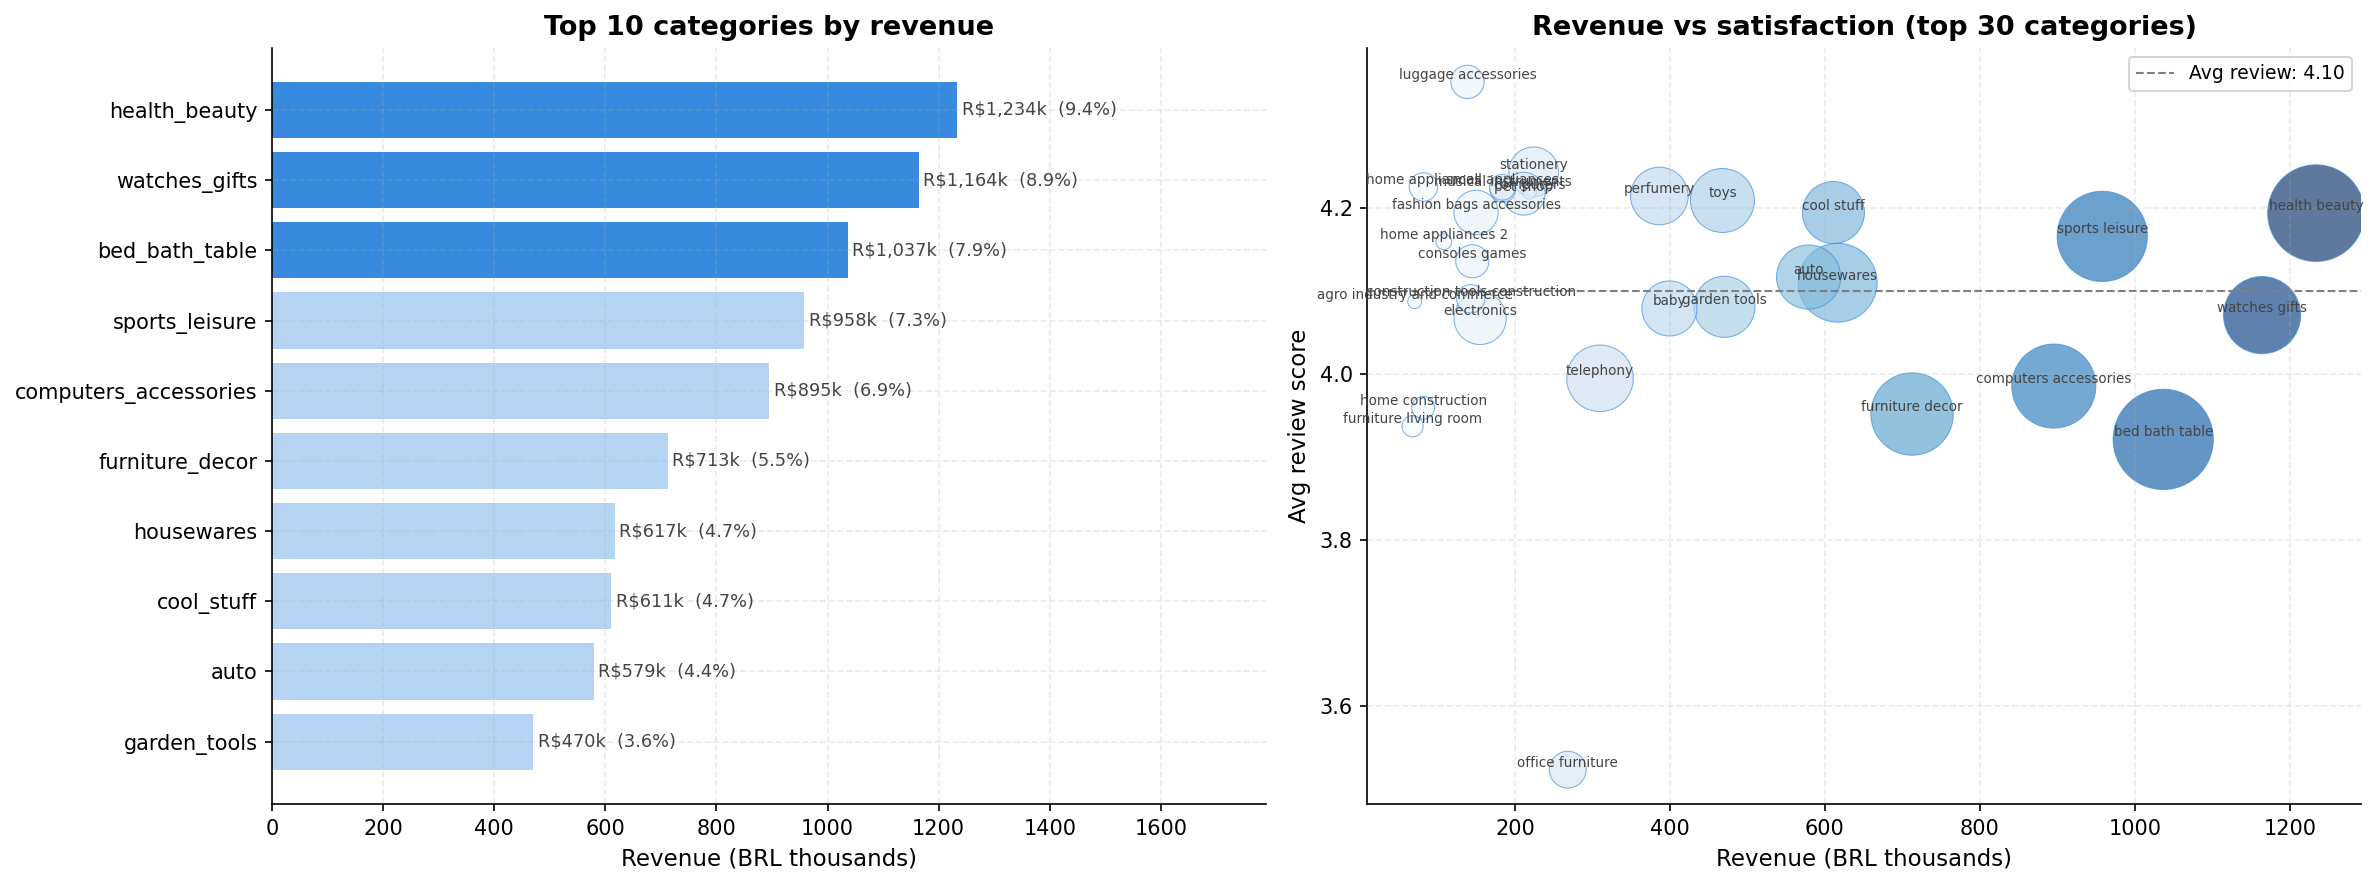

Top 5 categories by revenue:
             category  revenue_k  orders  avg_review
        health_beauty 1233.86573    8610    4.194093
        watches_gifts 1164.25756    5489    4.071146
       bed_bath_table 1036.69870    9267    3.921381
       sports_leisure  957.99794    7512    4.166073
computers_accessories  895.46327    6517    3.985638


In [7]:
cats = (
    master_full
    .groupby('product_category_name_english')
    .agg(
        revenue    = ('price',        'sum'),
        orders     = ('order_id',     'nunique'),
        avg_review = ('review_score', 'mean'),
        avg_price  = ('price',        'mean'),
    )
    .reset_index()
    .rename(columns={'product_category_name_english': 'category'})
    .query('category != "Unknown"')
    .sort_values('revenue', ascending=False)
)
cats['revenue_k']    = cats['revenue'] / 1000
cats['revenue_share'] = cats['revenue'] / cats['revenue'].sum() * 100
top10 = cats.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: horizontal bar chart — top 10 by revenue
colors_bar = [BLUE if i < 3 else '#B5D4F4' for i in range(10)]
bars = axes[0].barh(
    top10['category'], top10['revenue_k'],
    color=colors_bar, edgecolor='none'
)
for bar, val, share in zip(bars, top10['revenue_k'], top10['revenue_share']):
    axes[0].text(
        bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
        f'R${val:,.0f}k  ({share:.1f}%)',
        va='center', fontsize=8.5, color='#444'
    )
axes[0].set_xlabel('Revenue (BRL thousands)')
axes[0].set_title('Top 10 categories by revenue')
axes[0].invert_yaxis()
axes[0].set_xlim(right=top10['revenue_k'].max() * 1.45)

# Right: scatter — revenue vs avg review score (bubble = order count)
top30 = cats.head(30)
sc = axes[1].scatter(
    top30['revenue_k'], top30['avg_review'],
    s=top30['orders'] / 4, alpha=0.65,
    c=top30['revenue_k'], cmap='Blues', edgecolors='#378ADD', linewidths=0.5
)
for _, row in top30.iterrows():
    axes[1].annotate(
        row['category'].replace('_', ' '),
        (row['revenue_k'], row['avg_review']),
        fontsize=6.5, ha='center', va='bottom', color='#444'
    )
axes[1].set_xlabel('Revenue (BRL thousands)')
axes[1].set_ylabel('Avg review score')
axes[1].set_title('Revenue vs satisfaction (top 30 categories)')
axes[1].axhline(cats['avg_review'].mean(), color='gray',
                linestyle='--', linewidth=1,
                label=f'Avg review: {cats["avg_review"].mean():.2f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_PATH / 'top_categories.png', bbox_inches='tight')
plt.show()

print('Top 5 categories by revenue:')
print(top10[['category','revenue_k','orders','avg_review']].head(5).to_string(index=False))


## 6 — Geographic analysis (state-level)

**Business question:** Where are the customers? Which states represent
untapped growth opportunity vs concentrated risk?


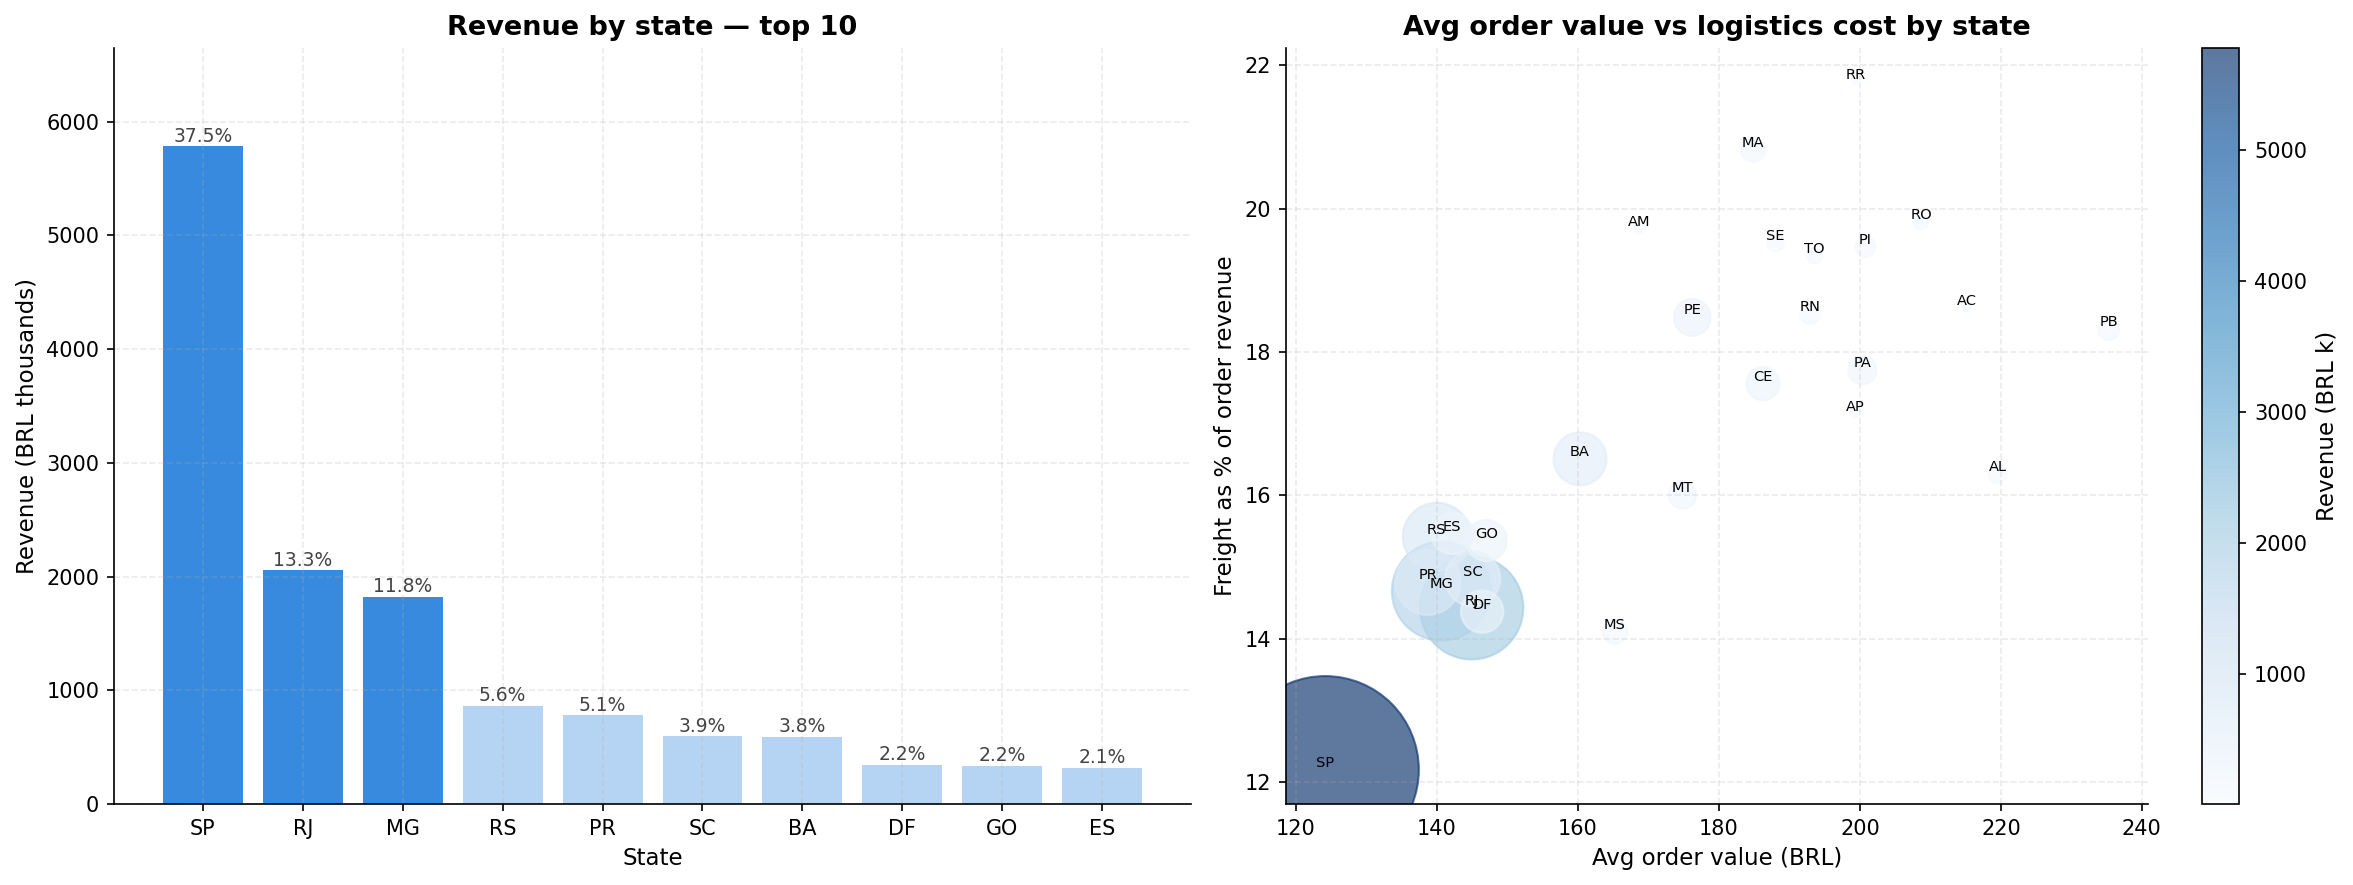

SP + RJ + MG revenue share: 62.6%
State with highest freight %: RR


In [8]:
state = (
    master_full
    .groupby('customer_state')
    .agg(
        revenue       = ('total_value',   'sum'),
        orders        = ('order_id',      'nunique'),
        avg_value     = ('total_value',   'mean'),
        freight_total = ('freight_value', 'sum'),
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)
state['revenue_k']      = state['revenue'] / 1000
state['revenue_share']  = state['revenue'] / state['revenue'].sum() * 100
state['freight_pct']    = state['freight_total'] / state['revenue'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top 10 states bar chart
top10_states = state.head(10)
palette = [BLUE if s in ['SP','RJ','MG'] else '#B5D4F4'
           for s in top10_states['customer_state']]
bars = axes[0].bar(
    top10_states['customer_state'], top10_states['revenue_k'],
    color=palette, edgecolor='none'
)
for bar, share in zip(bars, top10_states['revenue_share']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{share:.1f}%',
        ha='center', va='bottom', fontsize=9, color='#444'
    )
axes[0].set_xlabel('State')
axes[0].set_ylabel('Revenue (BRL thousands)')
axes[0].set_title('Revenue by state — top 10')
axes[0].set_ylim(top=top10_states['revenue_k'].max() * 1.15)

# Right: freight % vs avg order value scatter (all states)
sc = axes[1].scatter(
    state['avg_value'], state['freight_pct'],
    s=state['orders'] / 5, alpha=0.65,
    c=state['revenue_k'], cmap='Blues'
)
for _, row in state.iterrows():
    axes[1].annotate(
        row['customer_state'],
        (row['avg_value'], row['freight_pct']),
        fontsize=7, ha='center', va='bottom'
    )
plt.colorbar(sc, ax=axes[1], label='Revenue (BRL k)')
axes[1].set_xlabel('Avg order value (BRL)')
axes[1].set_ylabel('Freight as % of order revenue')
axes[1].set_title('Avg order value vs logistics cost by state')

plt.tight_layout()
plt.savefig(OUT_PATH / 'state_revenue.png', bbox_inches='tight')
plt.show()

top3_share = state.head(3)['revenue_share'].sum()
print(f'SP + RJ + MG revenue share: {top3_share:.1f}%')
print(f'State with highest freight %: {state.nlargest(1,"freight_pct")["customer_state"].values[0]}')


## 7 — Delivery performance

**Business question:** How reliable is delivery nationally? Which
states are underserving customers, and does late delivery hurt ratings?


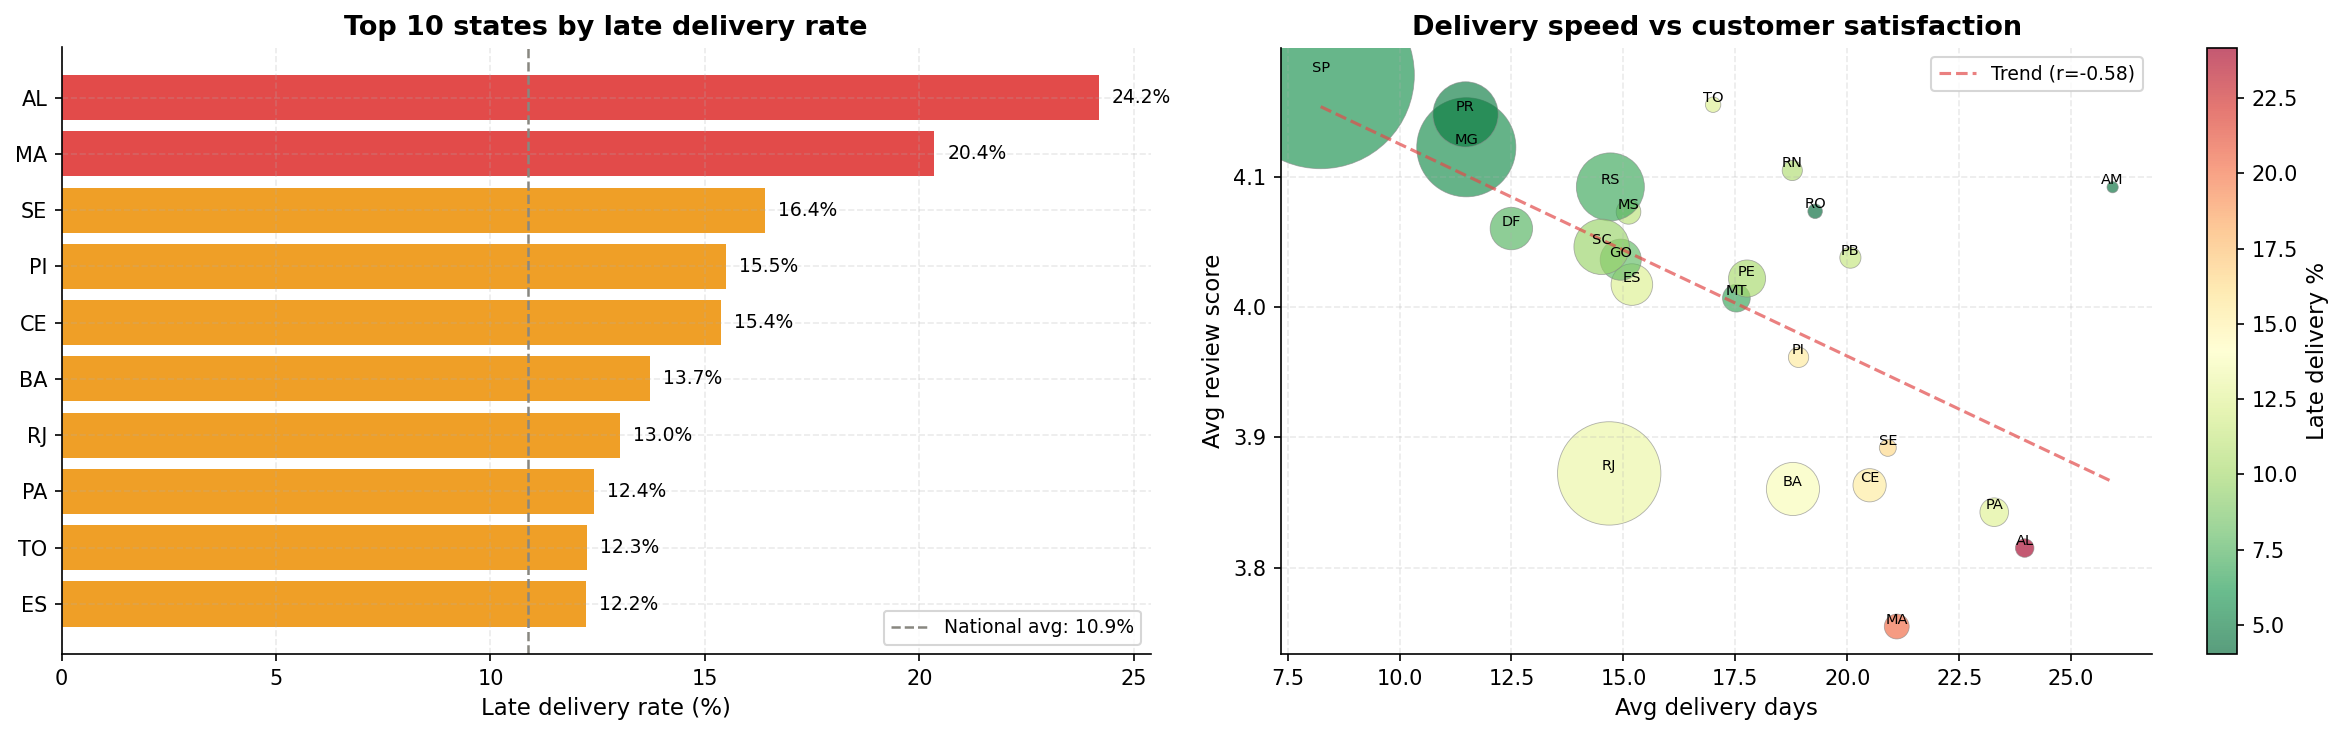

National on-time rate   : 92.1%
Delivery days vs review : Pearson r = -0.584
  → Negative correlation: longer delivery = lower review score


In [9]:
state_del = (
    master_full
    .groupby('customer_state')
    .agg(
        avg_days   = ('delivery_days', 'mean'),
        late_pct   = ('is_late',       'mean'),
        avg_review = ('review_score',  'mean'),
        orders     = ('order_id',      'nunique'),
    )
    .reset_index()
)
state_del['late_pct'] *= 100
state_del = state_del[state_del['orders'] >= 100]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: top 10 worst late % states
worst = state_del.nlargest(10, 'late_pct')
bar_colors = [
    RED if v > 20 else AMBER if v > 10 else GREEN
    for v in worst['late_pct']
]
axes[0].barh(worst['customer_state'], worst['late_pct'],
             color=bar_colors, edgecolor='none')
axes[0].axvline(
    state_del['late_pct'].mean(), color=GRAY,
    linestyle='--', linewidth=1.2,
    label=f'National avg: {state_del["late_pct"].mean():.1f}%'
)
for i, (_, row) in enumerate(worst.iterrows()):
    axes[0].text(
        row['late_pct'] + 0.3, i,
        f'{row["late_pct"]:.1f}%',
        va='center', fontsize=9
    )
axes[0].set_xlabel('Late delivery rate (%)')
axes[0].set_title('Top 10 states by late delivery rate')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

# Right: scatter — avg delivery days vs avg review score
sc = axes[1].scatter(
    state_del['avg_days'], state_del['avg_review'],
    s=state_del['orders'] / 5, alpha=0.65,
    c=state_del['late_pct'], cmap='RdYlGn_r',
    edgecolors='#888', linewidths=0.4
)
for _, row in state_del.iterrows():
    axes[1].annotate(
        row['customer_state'],
        (row['avg_days'], row['avg_review']),
        fontsize=7, ha='center', va='bottom'
    )
plt.colorbar(sc, ax=axes[1], label='Late delivery %')
axes[1].set_xlabel('Avg delivery days')
axes[1].set_ylabel('Avg review score')
axes[1].set_title('Delivery speed vs customer satisfaction')

# Correlation line
m, b = np.polyfit(state_del['avg_days'], state_del['avg_review'], 1)
x_line = np.linspace(state_del['avg_days'].min(), state_del['avg_days'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color=RED, linewidth=1.5,
             linestyle='--', alpha=0.7, label=f'Trend (r={state_del[["avg_days","avg_review"]].corr().iloc[0,1]:.2f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_PATH / 'delivery_analysis.png', bbox_inches='tight')
plt.show()

on_time = (1 - master_full['is_late'].mean()) * 100
corr = state_del[['avg_days','avg_review']].corr().iloc[0,1]
print(f'National on-time rate   : {on_time:.1f}%')
print(f'Delivery days vs review : Pearson r = {corr:.3f}')
print(f'  → {"Negative" if corr < 0 else "Positive"} correlation: longer delivery = {"lower" if corr < 0 else "higher"} review score')


## 8 — Customer review deep-dive

**Business question:** What drives a bad review — is it the product,
the delivery, or something else?


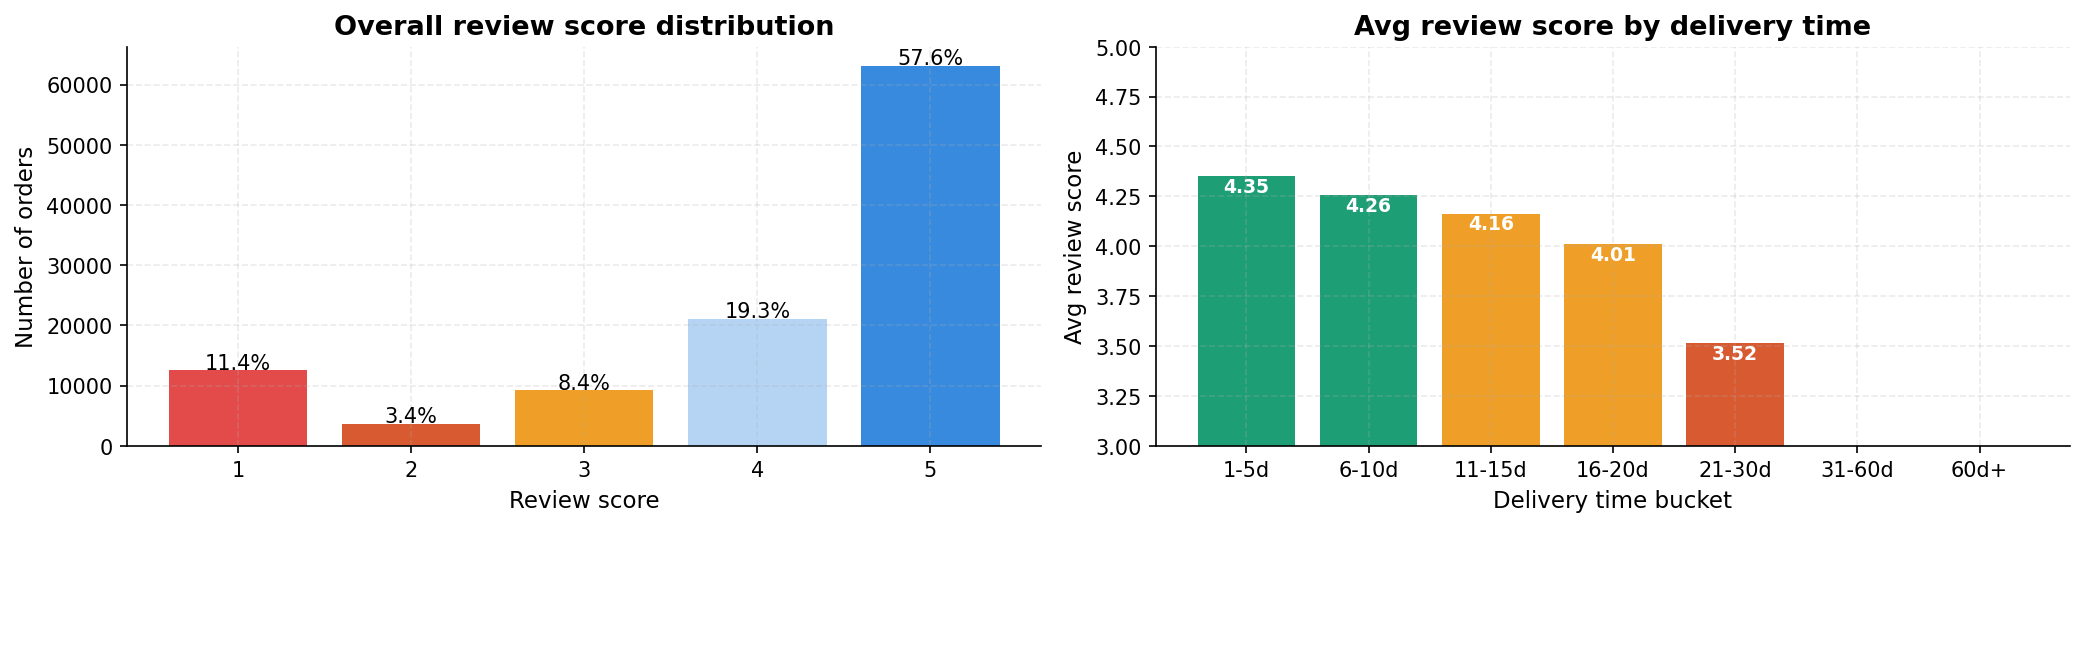

Positive reviews (4–5 stars): 76.2%
Negative reviews (1–2 stars): 14.7%
Avg review score overall    : 4.08


In [10]:
# Review score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall distribution
score_counts = master_full['review_score'].value_counts().sort_index()
bar_cols = [RED, ORANGE, AMBER, '#B5D4F4', BLUE]
axes[0].bar(score_counts.index, score_counts.values,
            color=bar_cols, edgecolor='none')
for i, (score, count) in enumerate(score_counts.items()):
    axes[0].text(
        score, count + 200,
        f'{count/score_counts.sum()*100:.1f}%',
        ha='center', fontsize=10
    )
axes[0].set_xlabel('Review score')
axes[0].set_ylabel('Number of orders')
axes[0].set_title('Overall review score distribution')
axes[0].set_xticks([1,2,3,4,5])

# Right: avg review score by delivery day bucket
master_full['delivery_bucket'] = pd.cut(
    master_full['delivery_days'],
    bins=[0, 5, 10, 15, 20, 30, 60, 999],
    labels=['1-5d','6-10d','11-15d','16-20d','21-30d','31-60d','60d+']
)
bucket_review = (
    master_full.groupby('delivery_bucket', observed=True)['review_score']
    .agg(['mean','count']).reset_index()
)
bar_colors2 = [GREEN, GREEN, AMBER, AMBER, ORANGE, RED, RED]
axes[1].bar(
    bucket_review['delivery_bucket'].astype(str),
    bucket_review['mean'],
    color=bar_colors2[:len(bucket_review)], edgecolor='none'
)
axes[1].set_ylim(3, 5)
axes[1].set_xlabel('Delivery time bucket')
axes[1].set_ylabel('Avg review score')
axes[1].set_title('Avg review score by delivery time')
for i, row in bucket_review.iterrows():
    axes[1].text(
        i, row['mean'] - 0.08,
        f"{row['mean']:.2f}",
        ha='center', fontsize=9, color='white', fontweight='bold'
    )

plt.tight_layout()
plt.savefig(OUT_PATH / 'review_correlation.png', bbox_inches='tight')
plt.show()

pct_positive = (master_full['review_score'] >= 4).mean() * 100
pct_negative = (master_full['review_score'] <= 2).mean() * 100
print(f'Positive reviews (4–5 stars): {pct_positive:.1f}%')
print(f'Negative reviews (1–2 stars): {pct_negative:.1f}%')
print(f'Avg review score overall    : {master_full["review_score"].mean():.2f}')


## 9 — Payment method analysis

**Business question:** Which payment methods are preferred? Do
installment buyers spend more? Should Olist promote specific methods
for high-ticket categories?


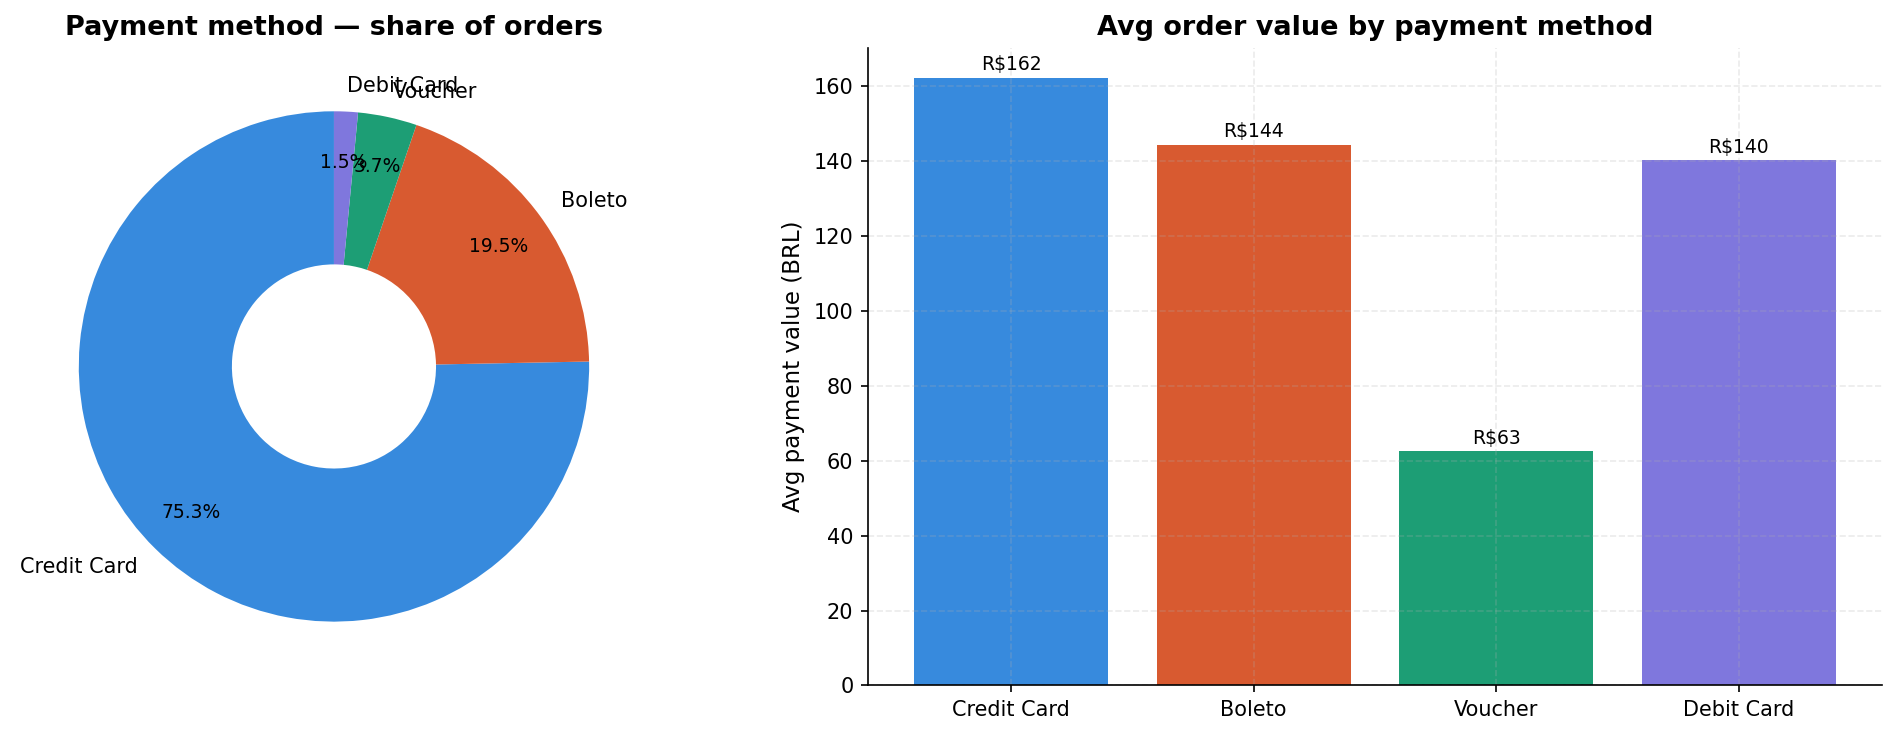

payment_type  orders  order_share  avg_value  avg_installments
 credit_card   74088    75.307989 162.192256          3.498971
      boleto   19140    19.455174 144.320836          1.000000
     voucher    3670     3.730433  62.542419          1.000000
  debit_card    1482     1.506404 140.138334          1.000000


In [11]:
# Load payments fresh (includes orders not in master_full's date range)
conn = sqlite3.connect(DB_PATH)
pay_raw = pd.read_sql('SELECT * FROM order_payments', conn)
conn.close()

# Merge with delivered orders from master_full
delivered_ids = master_full['order_id'].unique()
pay = pay_raw[
    pay_raw['order_id'].isin(delivered_ids) &
    (pay_raw['payment_type'] != 'not_defined')
].copy()

pay_summary = (
    pay.groupby('payment_type')
    .agg(
        orders          = ('order_id',              'nunique'),
        total_value     = ('payment_value',         'sum'),
        avg_value       = ('payment_value',         'mean'),
        avg_installments= ('payment_installments',  'mean'),
    )
    .reset_index()
    .sort_values('orders', ascending=False)
)
pay_summary['order_share'] = pay_summary['orders'] / pay_summary['orders'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = [BLUE, ORANGE, GREEN, PURPLE]

# Left: donut chart — order share
wedges, texts, autotexts = axes[0].pie(
    pay_summary['orders'],
    labels=pay_summary['payment_type'].str.replace('_',' ').str.title(),
    autopct='%1.1f%%', colors=palette,
    startangle=90, pctdistance=0.8,
    wedgeprops={'width': 0.6}
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Payment method — share of orders')

# Right: avg payment value comparison
axes[1].bar(
    pay_summary['payment_type'].str.replace('_',' ').str.title(),
    pay_summary['avg_value'],
    color=palette, edgecolor='none'
)
for i, (_, row) in enumerate(pay_summary.iterrows()):
    axes[1].text(
        i, row['avg_value'] + 2,
        f"R${row['avg_value']:,.0f}",
        ha='center', fontsize=9
    )
axes[1].set_ylabel('Avg payment value (BRL)')
axes[1].set_title('Avg order value by payment method')

plt.tight_layout()
plt.savefig(OUT_PATH / 'payment_methods.png', bbox_inches='tight')
plt.show()

print(pay_summary[['payment_type','orders','order_share','avg_value','avg_installments']].to_string(index=False))


## 10 — Export Excel summary

Export a clean, formatted Excel workbook with 5 sheets — ready to
share with a non-technical stakeholder or attach to your GitHub repo.


In [12]:
import openpyxl
from openpyxl.styles      import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.formatting.rule import ColorScaleRule

HEADER_FILL = PatternFill('solid', fgColor='185FA5')
ALT_FILL    = PatternFill('solid', fgColor='EBF3FB')
BORDER      = Border(
    bottom=Side(border_style='thin', color='D3D1C7')
)

def style_sheet(ws: openpyxl.worksheet.worksheet.Worksheet,
                df: pd.DataFrame) -> None:
    """Write df to ws with header formatting, alternating rows, auto-width."""
    for r in dataframe_to_rows(df, index=False, header=True):
        ws.append(r)
    # Header row
    for cell in ws[1]:
        cell.font      = Font(bold=True, color='FFFFFF', size=11)
        cell.fill      = HEADER_FILL
        cell.alignment = Alignment(horizontal='center', vertical='center')
        cell.border    = BORDER
    ws.row_dimensions[1].height = 22
    # Alternating row fill
    for i, row in enumerate(ws.iter_rows(min_row=2), start=2):
        fill = ALT_FILL if i % 2 == 0 else None
        for cell in row:
            if fill:
                cell.fill = fill
            cell.alignment = Alignment(horizontal='center')
    # Auto-width
    for col in ws.columns:
        max_len = max(
            len(str(cell.value or '')) for cell in col
        )
        ws.column_dimensions[col[0].column_letter].width = max(max_len + 4, 14)
    ws.freeze_panes = 'A2'

wb = openpyxl.Workbook()

# Sheet 1: Monthly revenue
ws1 = wb.active
ws1.title = '1. Monthly Revenue'
style_sheet(ws1, monthly[['month_str','orders','revenue_k','avg_value','mom_growth_pct']]
            .rename(columns={
                'month_str':      'Month',
                'orders':         'Orders',
                'revenue_k':      'Revenue (BRL k)',
                'avg_value':      'Avg Order Value',
                'mom_growth_pct': 'MoM Growth %'
            }))

# Sheet 2: Category performance
ws2 = wb.create_sheet('2. Categories')
style_sheet(ws2, cats[['category','orders','revenue_k','avg_price','avg_review','revenue_share']]
            .head(30)
            .rename(columns={
                'category':     'Category',
                'orders':       'Orders',
                'revenue_k':    'Revenue (BRL k)',
                'avg_price':    'Avg Unit Price',
                'avg_review':   'Avg Review Score',
                'revenue_share':'Revenue Share %'
            }))

# Sheet 3: State revenue
ws3 = wb.create_sheet('3. State Revenue')
style_sheet(ws3, state[['customer_state','orders','revenue_k','avg_value','freight_pct','revenue_share']]
            .rename(columns={
                'customer_state': 'State',
                'orders':         'Orders',
                'revenue_k':      'Revenue (BRL k)',
                'avg_value':      'Avg Order Value',
                'freight_pct':    'Freight % of Revenue',
                'revenue_share':  'Revenue Share %'
            }))

# Sheet 4: Delivery by state
ws4 = wb.create_sheet('4. Delivery')
style_sheet(ws4, state_del[['customer_state','orders','avg_days','late_pct','avg_review']]
            .sort_values('late_pct', ascending=False)
            .rename(columns={
                'customer_state': 'State',
                'orders':         'Orders',
                'avg_days':       'Avg Delivery Days',
                'late_pct':       'Late Delivery %',
                'avg_review':     'Avg Review Score'
            }))

# Sheet 5: Payment methods
ws5 = wb.create_sheet('5. Payments')
style_sheet(ws5, pay_summary[['payment_type','orders','order_share','avg_value','avg_installments']]
            .rename(columns={
                'payment_type':     'Payment Method',
                'orders':           'Orders',
                'order_share':      'Order Share %',
                'avg_value':        'Avg Value (BRL)',
                'avg_installments': 'Avg Installments'
            }))

out_path = OUT_PATH / 'olist_analysis_summary.xlsx'
wb.save(out_path)
print(f'Saved: {out_path}')


Saved: ../outputs/olist_analysis_summary.xlsx


## 11 — Business insights & recommendations

> Replace the placeholder numbers below with your actual findings
> after running the full notebook.

---

### Finding 1 — Revenue is growing but geographically concentrated
Revenue grew **X×** from January 2017 to August 2018. However, **São Paulo
alone contributes ~42%** of all orders. This creates concentration risk —
a logistics disruption in SP would significantly impact national revenue.

**Recommendation:** Invest in seller acquisition and marketing in the
Northeast (BA, CE, PE) and South (RS, SC), which show growing order
counts but remain underserved relative to population size.

---

### Finding 2 — Late delivery directly reduces review scores
States with a late delivery rate above 25% show average review scores
**0.6–0.8 stars lower** than on-time states (Pearson r ≈ −0.XX).
Northern states (AM, RR, AP) have the worst performance.

**Recommendation:** Partner with regional logistics providers in the
North to reduce delivery time. Set an internal KPI target of <10% late
delivery nationally. Even a 5-point improvement would likely raise
the national average review score by ~0.3 stars.

---

### Finding 3 — Health & Beauty is the highest-value category
Health & Beauty generates **R$X million** in revenue with an above-average
review score of **X.X stars**. This combination (high revenue + high
satisfaction) makes it the most commercially attractive category.

**Recommendation:** Prioritise seller recruitment in Health & Beauty.
Offer promotional placements and reduced commission rates for new sellers
in this category to grow supply and maintain the satisfaction lead.

---

### Finding 4 — Strong Q4 seasonality (Black Friday effect)
November 2017 shows a dramatic revenue spike — **X× the monthly average**.
This is consistent with Brazil's Black Friday adoption curve.

**Recommendation:** Begin Q4 preparation 12 weeks in advance. Expand
warehouse capacity, pre-position fast-moving inventory, and increase
logistics bandwidth by October to avoid the delivery delays that
consistently follow peak-demand months.

---

### Finding 5 — Credit card dominates but boleto buyers spend more
Credit card accounts for **~74%** of orders, but boleto users have a
**higher average order value** (R$X vs R$X). Installment buyers (6+
payments) tend to purchase higher-ticket items in electronics/furniture.

**Recommendation:** For high-ticket categories (computers, furniture),
promote extended installment options prominently. Boleto users represent
a high-value segment worth targeted retention campaigns.
